In [2]:
1+1

2

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import yfinance as yf

# Phase 0

## day 1 week 2

In [4]:
data = pd.read_csv('Nifty 50 Historical Data.csv')
data.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,20-07-2026,"24,238.50","24,190.05","24,264.60","24,136.85",353.10M,-0.39%
1,17-07-2026,"24,334.30","24,127.60","24,367.30","24,099.05",387.77M,1.09%
2,16-07-2026,"24,072.75","24,142.10","24,186.50","24,050.00",264.27M,-0.02%
3,15-07-2026,"24,078.50","24,085.85","24,220.35","24,010.55",306.92M,0.11%
4,14-07-2026,"24,052.05","24,068.00","24,157.10","24,023.70",355.83M,-0.66%


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      1239 non-null   str  
 1   Price     1239 non-null   str  
 2   Open      1239 non-null   str  
 3   High      1239 non-null   str  
 4   Low       1239 non-null   str  
 5   Vol.      1235 non-null   str  
 6   Change %  1239 non-null   str  
dtypes: str(7)
memory usage: 67.9 KB


In [6]:
data.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        4
Change %    0
dtype: int64

In [7]:
data[data.isnull().any(axis=1)]

,Date,Price,Open,High,Low,Vol.,Change %
597,19-02-2024,"22,122.25","22,103.45","22,186.65","22,021.05",NaN,0.37%
616,20-01-2024,"21,571.80","21,706.15","21,720.30","21,541.80",NaN,-0.23%
822,22-03-2023,"17,151.90","17,177.45","17,207.25","17,107.85",NaN,0.26%
972,16-08-2022,"17,825.25","17,797.20","17,839.10","17,764.05",NaN,0.72%


In [8]:
data.describe()

,Date,Price,Open,High,Low,Vol.,Change %
count,1239,1239,1239,1239,1239,1235,1239
unique,1239,1234,1237,1234,1238,1210,349
top,20-07-2026,"25,910.05","19,784.00","24,087.45","17,774.25",338.22M,0.14%
freq,1,2,2,2,2,2,13


In [9]:
datatypes = data.dtypes
datatypes

Date        str
Price       str
Open        str
High        str
Low         str
Vol.        str
Change %    str
dtype: object

In [10]:
# Strip the 'M' from the string
data['Vol.'] = data['Vol.'].str.replace('M', '', regex=False)
data['Vol.'] = data['Vol.'].str.replace('B', '', regex=False)
# Convert to float
data['Vol.'] = data['Vol.'].astype(float)

In [11]:
mean_vol = data['Vol.'].mean()
data['Vol.'] = data['Vol.'].fillna(mean_vol)

In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1239 non-null   str    
 1   Price     1239 non-null   str    
 2   Open      1239 non-null   str    
 3   High      1239 non-null   str    
 4   Low       1239 non-null   str    
 5   Vol.      1239 non-null   float64
 6   Change %  1239 non-null   str    
dtypes: float64(1), str(6)
memory usage: 67.9 KB


In [13]:
data['Change %'] = data['Change %'].str.replace('%', '', regex=False)
data['Change %'] = data['Change %'].astype(float)

In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1239 non-null   str    
 1   Price     1239 non-null   str    
 2   Open      1239 non-null   str    
 3   High      1239 non-null   str    
 4   Low       1239 non-null   str    
 5   Vol.      1239 non-null   float64
 6   Change %  1239 non-null   float64
dtypes: float64(2), str(5)
memory usage: 67.9 KB


In [15]:
count = (abs(data['Change %']) > 2).sum()
count

np.int64(39)

## day 2 week 2

In [16]:
data['Price'] = data['Price'].str.replace(',', '', regex=False).astype(float)

In [17]:
log_returns = np.log(data['Price'] / data['Price'].shift(1))
log_returns = log_returns.dropna() # removes the first NaN value
log_returns.head()

1    0.003945
2   -0.010806
3    0.000239
4   -0.001099
5    0.006587
Name: Price, dtype: float64

In [18]:
# adding log returns, rolling mean 20, 50 to data
data['Log Returns'] = log_returns
data['MA20'] = data['Price'].rolling(window=20).mean()
data['MA50'] = data['Price'].rolling(window=50).mean()
data.tail()


,Date,Price,Open,High,Low,Vol.,Change %,Log Returns,MA20,MA50
1234,27-07-2021,15746.45,"15,860.50","15,881.55","15,701.00",311.01,-0.49,0.002356,16241.8500,16944.990
1235,26-07-2021,15824.45,"15,849.30","15,893.35","15,797.00",267.08,-0.20,0.004941,16201.8425,16908.559
1236,23-07-2021,15856.05,"15,856.80","15,899.80","15,768.40",294.10,0.20,0.001995,16169.8225,16869.234
1237,22-07-2021,15824.05,"15,736.60","15,834.80","15,726.40",265.25,1.23,-0.002020,16138.5000,16831.890
1238,20-07-2021,15632.10,"15,703.95","15,728.45","15,578.55",274.28,-0.76,-0.012204,16091.6625,16793.891


In [19]:
volatility = data['Log Returns'].rolling(window = 20).std()* np.sqrt(252)
volatility.tail()
volatility.mean()


np.float64(0.12927875946575834)

## week 2 day 3

In [20]:
ticker = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'WIPRO.NS']
raw_data =  yf.download(ticker, period = '1y', interval = '1d')
raw_data.head()

[*********************100%***********************]  5 of 5 completed


Price            Close                                                     \
Ticker     HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS    WIPRO.NS   
Date                                                                        
2025-07-31  992.681580  1454.767090  1378.296997  2915.758545  239.317657   
2025-08-01  989.730408  1416.782959  1381.767090  2883.305664  233.968430   
2025-08-04  979.794739  1427.291260  1399.414673  2951.859863  237.149048   
2025-08-05  972.711853  1407.817383  1379.784180  2941.778564  237.014114   
2025-08-06  976.499268  1385.065430  1380.874878  2911.437988  231.279358   

Price             High                                                     \
Ticker     HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS    WIPRO.NS   
Date                                                                        
2025-07-31  999.174231  1472.216559  1390.590852  2937.841805  241.100724   
2025-08-01  997.649480  1444.837089  1393.862706  2915.758502  237.968296   
2025-08-04  992.829157  1429.508646  1403.975263  2956.660572  237.505658   
2025-08-05  980.975206  1425.555999  1398.918981  2954.836588  238.016486   
2025-08-06  977.827279  1403.768224  1383.948311  2944.562880  237.100852   

Price       ...        Open                                         \
Ticker      ... HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS   
Date        ...                                                      
2025-07-31  ...  990.910878  1455.441885  1376.215002  2920.463146   
2025-08-01  ...  990.615788  1440.209671  1375.025384  2909.133383   
2025-08-04  ...  988.697480  1408.974114  1383.155066  2889.162791   
2025-08-05  ...  977.089462  1425.555999  1398.918981  2951.860054   
2025-08-06  ...  969.514751  1399.815600  1379.982560  2940.914294   

Price                       Volume                                          
Ticker        WIPRO.NS HDFCBANK.NS   INFY.NS RELIANCE.NS   TCS.NS WIPRO.NS  
Date                                                                        
2025-07-31  239.124895    22183032   6851407    17065827  2968371  7338764  
2025-08-01  237.582772    11317258   8702978    10321171  2053847  7436999  
2025-08-04  233.968424    13933946   8610216     6312820  2519252  5234393  
2025-08-05  237.149049    23978058  10213323     9315972  1927996  7383968  
2025-08-06  237.100852    14080204  10566934     5834312  1487081  7700190  

[5 rows x 25 columns]

In [21]:
close_data = raw_data['Close']
close_data.head()

Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS,WIPRO.NS
Date,,,,,
2025-07-31,992.681580,1454.767090,1378.296997,2915.758545,239.317657
2025-08-01,989.730408,1416.782959,1381.767090,2883.305664,233.968430
2025-08-04,979.794739,1427.291260,1399.414673,2951.859863,237.149048
2025-08-05,972.711853,1407.817383,1379.784180,2941.778564,237.014114
2025-08-06,976.499268,1385.065430,1380.874878,2911.437988,231.279358


In [22]:
close_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 250 entries, 2025-07-31 to 2026-07-31
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   HDFCBANK.NS  250 non-null    float64
 1   INFY.NS      250 non-null    float64
 2   RELIANCE.NS  250 non-null    float64
 3   TCS.NS       250 non-null    float64
 4   WIPRO.NS     250 non-null    float64
dtypes: float64(5)
memory usage: 11.7 KB


In [23]:
correlation = close_data.corr()
correlation

Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS,WIPRO.NS
Ticker,,,,,
HDFCBANK.NS,1.000000,0.845047,0.701291,0.896192,0.877283
INFY.NS,0.845047,1.000000,0.752604,0.973108,0.944213
RELIANCE.NS,0.701291,0.752604,1.000000,0.743510,0.736620
TCS.NS,0.896192,0.973108,0.743510,1.000000,0.970243
WIPRO.NS,0.877283,0.944213,0.736620,0.970243,1.000000


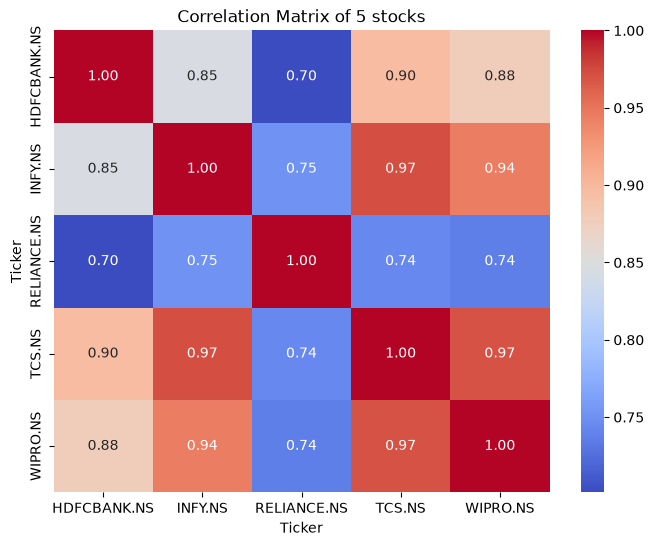

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of 5 stocks')
plt.show()

## week 2 day 4

**Portfolio Variance**: Calculated as $w^T \Sigma w$, where $w$ is the array of asset weights and $\Sigma$ (Sigma) is the covariance matrix of the asset returns. You take the square root of this variance to get the portfolio's volatility ($\sigma_p$).

**Sharpe Ratio**: Calculated as $\frac{R_p - R_f}{\sigma_p}$. It measures excess return per unit of risk. You subtract the risk-free rate ($R_f$, which is 0.065 for India) from your portfolio's annualized return ($R_p$) and divide by the portfolio's annualized volatility ($\sigma_p$).

**Max Drawdown**: The largest percentage drop from a peak to a trough before a new peak is achieved.

In [25]:
#risk_free_rate
rf = 0.065
returns = close_data.pct_change().dropna() # this is the returns of the assets
n_assets = len(returns.columns)
w = np.ones(n_assets)/n_assets #w is the array of asset weitghts
cov_matrix = returns.cov() * 252 # this is the covariance matrix of the returns
port_var = np.dot(w.T, np.dot(cov_matrix,w)) # this is portfilo variance
port_var




np.float64(0.030991481371457838)

In [26]:
anual_returns = returns.mean() * 252
portfolio_return = np.dot(w, anual_returns)

sharpe_ratio = (portfolio_return - rf) / np.sqrt(port_var)
sharpe_ratio



np.float64(-1.4145557758328144)

## week 2 day 5

## mini stock analyser

In [27]:
def analyse_stock(ticker, start, end):
    data = yf.download(ticker, start=start, end=end)
    data['Log Returns'] = np.log(data['Open'] / data['Open'].shift(1))
    annual_return = data['Log Returns'].mean() * 252
    annual_volatility = data['Log Returns'].std() * np.sqrt(252)
    sharpe_ratio = (annual_return - rf)/annual_volatility
    max_drawdown = (data['Close']/ data['Close'].cummax() - 1).min()
    best_day = data['Log Returns'].idxmax()
    worst_day = data['Log Returns'].idxmin()
    return print(f"""
        'annual return': {annual_return}
        'annual volatility': {annual_volatility}
        'sharpe ratio': {sharpe_ratio}
        'max drawdown': {max_drawdown}
        'best day': {best_day}
        'worst day': {worst_day}
    """)
    

In [29]:
analysis = analyse_stock('RELIANCE.NS', '2025-02-01', '2026-02-01')
# print(analysis)

$RELIANCE.NS: possibly delisted; no price data found  (1d 2025-02-01 -> 2026-02-01)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['RELIANCE.NS']: possibly delisted; no price data found  (1d 2025-02-01 -> 2026-02-01)


ValueError: attempt to get argmax of an empty sequence

## week 3 day 1

In [35]:
data = yf.download('RELIANCE.NS', start='2025-01-01', end='2026-01-01')
data['Log Returns'] = np.log(data['Open'] / data['Open'].shift(1))
data['rolling_volatility'] = data['Log Returns'].rolling(window=20).std() * np.sqrt(252)
data


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Log Returns,rolling_volatility
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,
Date,,,,,,,
2025-01-01,1210.793579,1215.800389,1201.226179,1204.448352,5892590,NaN,NaN
2025-01-02,1231.167725,1233.794938,1209.554328,1210.793626,15486276,0.005254,NaN
2025-01-03,1240.437622,1251.244320,1224.921594,1233.249697,15521102,0.018377,NaN
2025-01-06,1207.571533,1251.194807,1204.597219,1243.213682,14816766,0.008047,NaN
2025-01-07,1230.225708,1233.844481,1210.793549,1211.537128,10070505,-0.025810,NaN
...,...,...,...,...,...,...,...
2025-12-24,1551.028687,1568.448147,1546.449881,1565.461954,8815745,-0.005200,0.131274
2025-12-26,1552.024048,1553.815812,1547.146696,1547.544758,2311495,-0.011511,0.115296


In [ ]:
data['MA20'] = data['Open'].rolling(window=20).mean()
data['MA50'] = data['Open'].rolling(window=50).mean()
data['MA20/MA50'] = data['MA20'] / data['MA50']
data

Price,Close,High,Low,Open,Volume,Log Returns,rolling_volatility,MA20,MA50,MA20/MA50
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,,,,
Date,,,,,,,,,,
2025-01-01,1210.793579,1215.800389,1201.226179,1204.448352,5892590,NaN,NaN,NaN,NaN,NaN
2025-01-02,1231.167725,1233.794938,1209.554328,1210.793626,15486276,0.005254,NaN,NaN,NaN,NaN
2025-01-03,1240.437622,1251.244320,1224.921594,1233.249697,15521102,0.018377,NaN,NaN,NaN,NaN
2025-01-06,1207.571533,1251.194807,1204.597219,1243.213682,14816766,0.008047,NaN,NaN,NaN,NaN
2025-01-07,1230.225708,1233.844481,1210.793549,1211.537128,10070505,-0.025810,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,1551.028687,1568.448147,1546.449881,1565.461954,8815745,-0.005200,0.131274,1545.593809,1504.294758,1.027454
2025-12-26,1552.024048,1553.815812,1547.146696,1547.544758,2311495,-0.011511,0.115296,1544.583482,1507.772676,1.024414


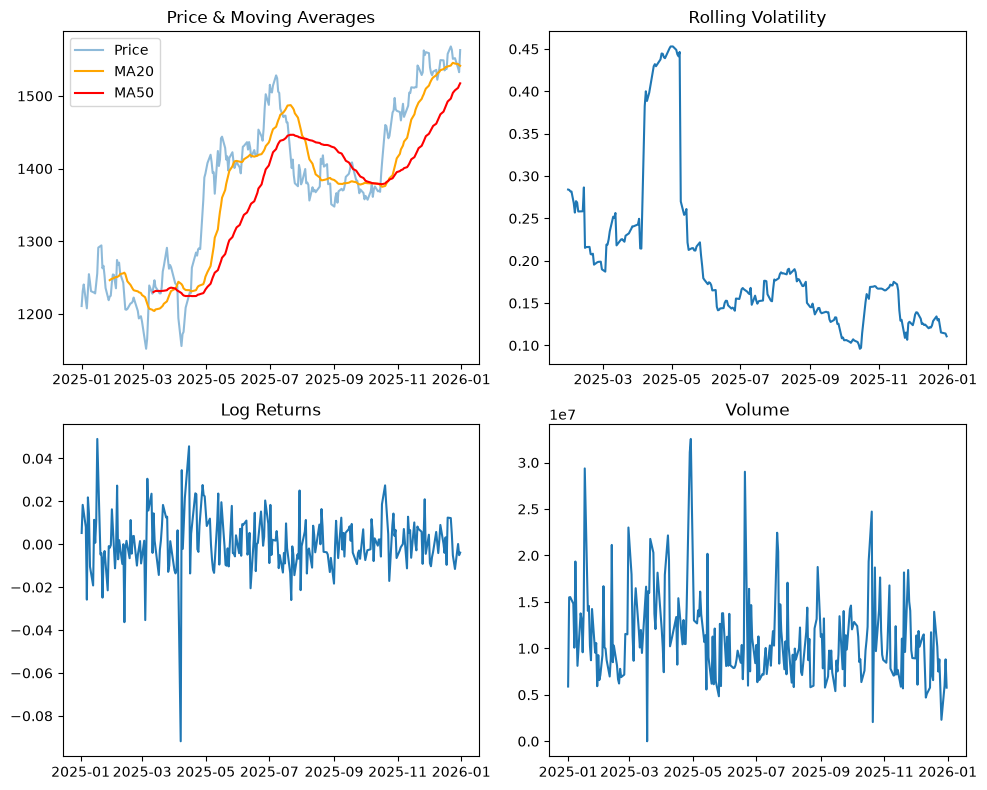

In [ ]:
data.dropna()
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize=(10,8))

ax[0,0].plot(data.index, data['Close'], label='Price', alpha=0.5)
ax[0,0].plot(data.index, data['MA20'], label='MA20', color='orange')
ax[0,0].plot(data.index, data['MA50'], label='MA50', color='red')
ax[0,0].set_title('Price & Moving Averages')
ax[0,0].legend()

ax[0,1].plot(data['rolling_volatility'])
ax[0,1].set_title('Rolling Volatility')

ax[1,0].plot(data['Log Returns'])
ax[1,0].set_title('Log Returns')

ax[1,1].plot(data['Volume'])
ax[1,1].set_title('Volume')

plt.tight_layout()
plt.show()


## week 3 day 2

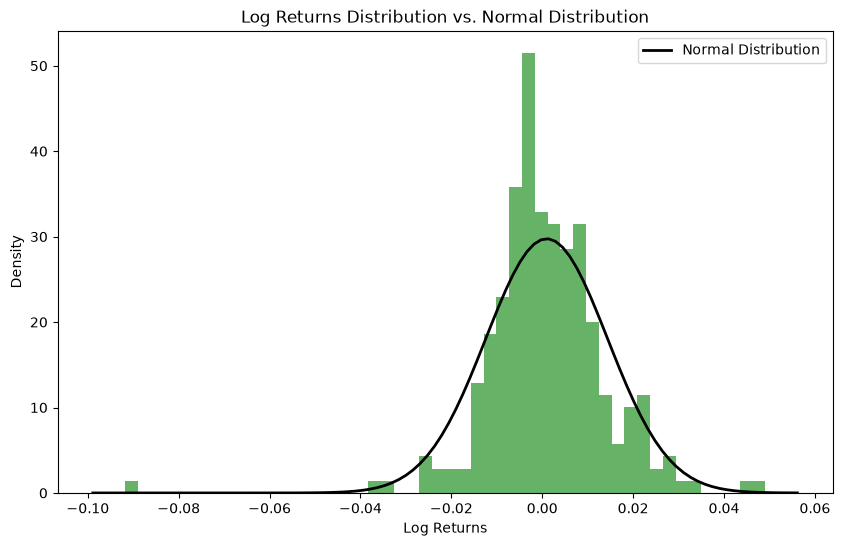

In [36]:
from scipy.stats import norm

returns = data['Log Returns'].dropna()
mu = returns.mean()
sigma = returns.std()

plt.figure(figsize=(10,6))
plt.hist(returns, bins=50, density=True, alpha=0.6, color='g')

xmin,xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, sigma)

plt.plot(x, p, 'k', linewidth=2, label='Normal Distribution')


plt.title('Log Returns Distribution vs. Normal Distribution')
plt.xlabel('Log Returns')
plt.ylabel('Density')
plt.legend()
plt.show()



## week 3 day 3

In [38]:
data = yf.download('RELIANCE.NS', start='2025-01-01', end='2026-01-01')
data['Log Returns'] = np.log(data['Open'] / data['Open'].shift(1))
data['rolling_volatility'] = data['Log Returns'].rolling(window=20).std() * np.sqrt(252)
data


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Log Returns,rolling_volatility
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,
Date,,,,,,,
2025-01-01,1210.793579,1215.800389,1201.226179,1204.448352,5892590,NaN,NaN
2025-01-02,1231.167725,1233.794938,1209.554328,1210.793626,15486276,0.005254,NaN
2025-01-03,1240.437622,1251.244320,1224.921594,1233.249697,15521102,0.018377,NaN
2025-01-06,1207.571533,1251.194807,1204.597219,1243.213682,14816766,0.008047,NaN
2025-01-07,1230.225708,1233.844481,1210.793549,1211.537128,10070505,-0.025810,NaN
...,...,...,...,...,...,...,...
2025-12-24,1551.028687,1568.448147,1546.449881,1565.461954,8815745,-0.005200,0.131274
2025-12-26,1552.024048,1553.815812,1547.146696,1547.544758,2311495,-0.011511,0.115296


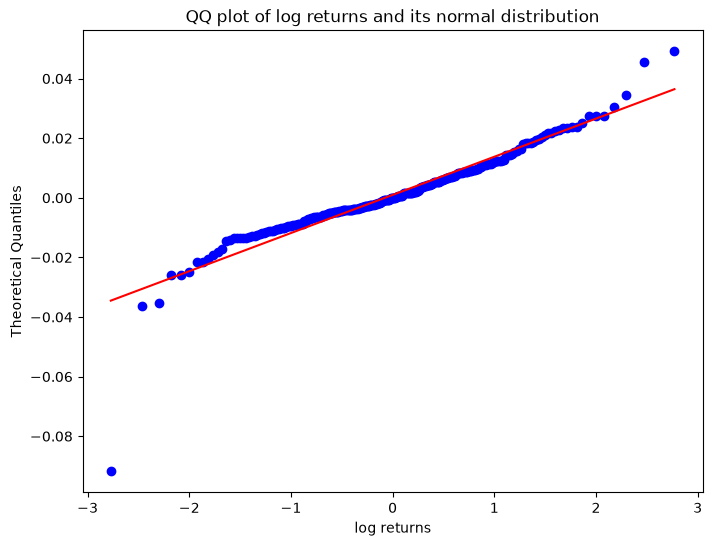

In [41]:

returns = data['Log Returns'].dropna()

# lets make a QQ plot to compare the quantiles of the log returns with the quantiles of a normal distribution.
import scipy.stats as stats

plt.figure(figsize=(8,6))
stats.probplot(returns, dist='norm', plot=plt)
plt.title('QQ plot of log returns and its normal distribution')
plt.xlabel('log returns')
plt.ylabel('Theoretical Quantiles')
plt.show()


In [42]:
# next step is to calculate the excess kurtosis (to measure the exact "fatness" of the tails) and skewness (to measure the asymmetry between the left and right tails) using scipy.stats
excess_kurtosis = stats.kurtosis(returns, fisher=True)
skewness = stats.skew(returns)
excess_kurtosis, skewness

(np.float64(9.347707787335212), np.float64(-0.9456775213136903))

In [43]:
# since exc_kurtosis > 0, this means extreme events (both positive and negative) happen far more frequently than a Gaussian model expects
# since skewness < 0, this means prob of negative returns is more than prob of positive returns
